In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import DataLoader, TensorDataset


In [2]:
# 1. Synthetic Data 
# 2. Plain causal 1d CNN (no dilation) 
# 3. with dilation 
# 4. verify with least squares fit 

In [3]:
np.random.seed(42) 
n = 5000 # samples 
phi1, phi2 = 0.6, -0.3 # cnn will learn this 
sigma = 1.0 # volatility 

y = np.zeros(n) 
y[0] = np.random.randn() * sigma 
y[1] = np.random.randn() * sigma 

# y represents log returns (stationary)
# price series equivalent is y.cumsum() 

# AR(2) generation: y_t = phi1 * y_t-1 + phi2 * y_t-2 + e
for t in range(2, n): 
    eps =  np.random.randn() * sigma 
    y[t] = phi1 * y[t - 1] + phi2 * y[t - 2] + eps 



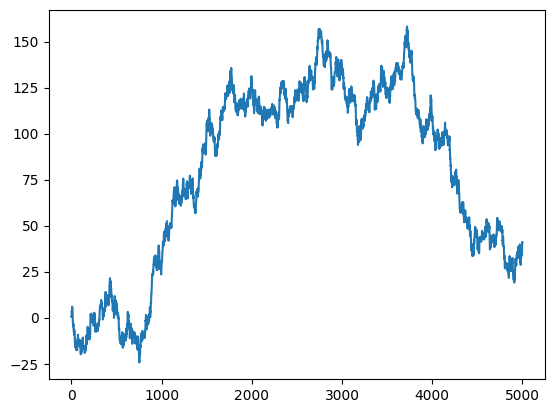

In [4]:
plt.plot(y.cumsum())

<StemContainer object of 3 artists>

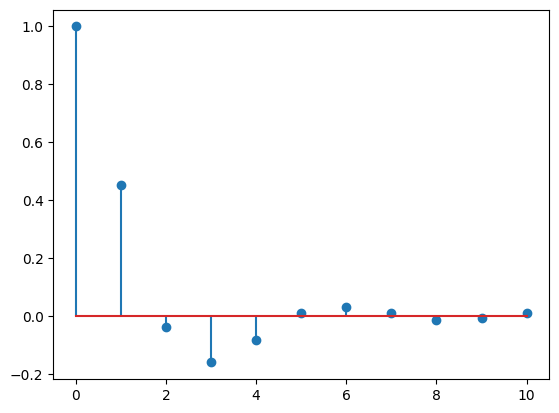

In [5]:
from statsmodels.tsa.stattools import acf 
a = acf(y, nlags=10)
plt.stem(a)

In [6]:
# 1d cnn, no dilation. only shape mechanics + causal padding (asymmetric) 

class CausalCNN(nn.Module): 
    def __init__(self, in_ch: int = 1, hidden: int = 16, kernel: int = 3, verbose: bool = False): 
        super().__init__() 
        self.kernel = kernel 
        self.conv1 = nn.Conv1d(in_channels=in_ch, out_channels=hidden, kernel_size=kernel) 
        # no pooling - architecture 
        self.conv2 = nn.Conv1d(in_channels=hidden, out_channels=hidden, kernel_size=kernel) 
        self.conv3 = nn.Conv1d(in_channels=hidden, out_channels=hidden, kernel_size=kernel) 
        self.head = nn.Linear(hidden, 1) # predict next value 
        # More stacks + nonlinearity between them = more expressiveness
        # can represent more complex (nonlinear, compositional) functions.
        self.verbose = verbose
    
    def forward(self, x): 
        # x shape (batch, 1, time) 
        pad = self.kernel - 1 # =2 for kernel 3 
        # adds padding to x with (pad - left) and (0 right) 
        # [pad1, pad2, x] 
        # if F.pad(x, (1, 1)) - symmetric padding - leakage. 
        # we do asymmentric padding (t-1) only to avoide looking into the future (causal padding)
        x = F.pad(x, (pad, 0)) 
        if self.verbose: 
            print("F.pad ", x.shape)
        x = F.relu(self.conv1(x)) 
        if self.verbose: 
            print("F.relu ", x.shape)
        # outputs 1 value so we have to pad again 
        x = F.pad(x, (pad, 0))  
        if self.verbose: 
            print("F.pad ", x.shape)
        x = F.relu(self.conv2(x)) 
        if self.verbose: 
            print("F.relu ", x.shape)
        x = F.pad(x, (pad, 0)) 
        if self.verbose: 
            print("F.pad ", x.shape)
        x = F.relu(self.conv3(x)) 
        if self.verbose: 
            print("F.relu ", x.shape)

        # take only last time step 
        x = x[:, :, -1] 
        if self.verbose: 
            print("last ", x.shape) 
        prediction = self.head(x).squeeze(-1) 
        if self.verbose: 
            print("prediction ", prediction.shape)
        return prediction
    
model = CausalCNN(verbose=True) 
print(model)

CausalCNN(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,))
  (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,))
  (conv3): Conv1d(16, 16, kernel_size=(3,), stride=(1,))
  (head): Linear(in_features=16, out_features=1, bias=True)
)


In [7]:
y_tensor = torch.from_numpy(y).float() 
y_tensor

tensor([ 0.4967, -0.1383,  0.4157,  ...,  3.5624,  2.7773, -0.2504])

In [8]:
# model expects (batch, channels, time). time dimension has to be a  fixed length the model is built for 
# BUT y is 5000 timesteps. Can't feed all 5000 into a model that is designed for 16. 
# so we need to construct training examples by sliding a window through the time series that captures 16 samples. 
# each window becomes one training example: input = past 16 values, target = next value. 
# 5000 timesteps -> ~4984 overlapping (X, Y) pairs to train on 


In [9]:
# pytorch standard way of doing sliding windows
# window = 16
# windows = y_tensor.unfold(0, window+1, 1)
# X = windows[:, :-1].unsqueeze(1) # (N, 1, window) # features  
# Y = windows[:, -1] # labels 

In [10]:
# manual sliding window 
window = 16 
X = [] 
Y = [] 

for t in range(window, len(y)): 
    X.append(y[t-window:t]) # past 16 values 
    Y.append(y[t]) 

X = torch.tensor(X).float().unsqueeze(1) # (N, 1, 16) = (batch, channels, time) 
Y = torch.tensor(Y).float() # (N,) 
print(X.shape)
print(Y.shape)

torch.Size([4984, 1, 16])
torch.Size([4984])


D:\TEMP\ipykernel_32204\4047830206.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  X = torch.tensor(X).float().unsqueeze(1) # (N, 1, 16) = (batch, channels, time)


In [11]:
dataset = TensorDataset(X, Y) 
loader = DataLoader(dataset, batch_size=64, shuffle=True) # fine to shuffle

xb, yb = next(iter(loader))
print(xb.shape, yb.shape)

torch.Size([64, 1, 16]) torch.Size([64])


In [12]:
out = model(xb) 
print(out.shape)

F.pad  torch.Size([64, 1, 18])
F.relu  torch.Size([64, 16, 16])
F.pad  torch.Size([64, 16, 18])
F.relu  torch.Size([64, 16, 16])
F.pad  torch.Size([64, 16, 18])
F.relu  torch.Size([64, 16, 16])
last  torch.Size([64, 16])
prediction  torch.Size([64])
torch.Size([64])


In [13]:
from datetime import datetime 
import torch.optim as optim

start = datetime.now() 

model = CausalCNN() 
loss_fn = nn.MSELoss()                                  # ← regression, not classification
optimizer = optim.Adam(model.parameters(), lr=1e-3) 

n_epochs = 50                                            # ← AR(2) needs more than 5 to converge

for epoch in range(n_epochs): 
    model.train() 
    running_loss = 0.0 

    for xb, yb in loader:                                # ← was `for images, labels in loader`
        optimizer.zero_grad()
        pred = model(xb)                                 # ← was `model(xb)` but xb wasn't defined
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}") 

end = datetime.now() 
training_time = (end - start).total_seconds() 
print(f"Total Training Time: {training_time:.1f} seconds")

Epoch   1: MSE = 1.3114
Epoch   2: MSE = 1.0574
Epoch   3: MSE = 1.0075
Epoch   4: MSE = 1.0002
Epoch   5: MSE = 0.9990
Epoch   6: MSE = 0.9936
Epoch   7: MSE = 0.9968
Epoch   8: MSE = 0.9946
Epoch   9: MSE = 0.9949
Epoch  10: MSE = 0.9919
Epoch  11: MSE = 0.9911
Epoch  12: MSE = 0.9936
Epoch  13: MSE = 0.9907
Epoch  14: MSE = 0.9928
Epoch  15: MSE = 0.9962
Epoch  16: MSE = 0.9879
Epoch  17: MSE = 0.9883
Epoch  18: MSE = 0.9854
Epoch  19: MSE = 0.9855
Epoch  20: MSE = 0.9859
Epoch  21: MSE = 0.9870
Epoch  22: MSE = 0.9843
Epoch  23: MSE = 0.9883
Epoch  24: MSE = 0.9890
Epoch  25: MSE = 0.9852
Epoch  26: MSE = 0.9847
Epoch  27: MSE = 0.9857
Epoch  28: MSE = 0.9830
Epoch  29: MSE = 0.9850
Epoch  30: MSE = 0.9787
Epoch  31: MSE = 0.9816
Epoch  32: MSE = 0.9782
Epoch  33: MSE = 0.9782
Epoch  34: MSE = 0.9794
Epoch  35: MSE = 0.9825
Epoch  36: MSE = 0.9809
Epoch  37: MSE = 0.9773
Epoch  38: MSE = 0.9765
Epoch  39: MSE = 0.9779
Epoch  40: MSE = 0.9762
Epoch  41: MSE = 0.9745
Epoch  42: MSE =

In [14]:
# Chronological split: first 80% = train, last 20% = test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

train_ds = TensorDataset(X_train, Y_train)
test_ds  = TensorDataset(X_test,  Y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)   # shuffle ok within train
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)  # don't shuffle test

In [15]:
from datetime import datetime 
import torch.optim as optim

start = datetime.now() 

model = CausalCNN() 
loss_fn = nn.MSELoss()                                  # ← regression, not classification
optimizer = optim.Adam(model.parameters(), lr=1e-3) 

n_epochs = 50                                            # ← AR(2) needs more than 5 to converge

for epoch in range(n_epochs): 
    model.train() 
    running_loss = 0.0 

    for xb, yb in train_loader:                                # ← was `for images, labels in loader`
        optimizer.zero_grad()
        pred = model(xb)                                 # ← was `model(xb)` but xb wasn't defined
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}") 

end = datetime.now() 
training_time = (end - start).total_seconds() 
print(f"Total Training Time: {training_time:.1f} seconds")

Epoch   1: MSE = 1.3243
Epoch   2: MSE = 1.1191
Epoch   3: MSE = 1.0174
Epoch   4: MSE = 0.9992
Epoch   5: MSE = 0.9947
Epoch   6: MSE = 0.9846
Epoch   7: MSE = 0.9983
Epoch   8: MSE = 0.9920
Epoch   9: MSE = 0.9870
Epoch  10: MSE = 0.9800
Epoch  11: MSE = 0.9821
Epoch  12: MSE = 0.9892
Epoch  13: MSE = 0.9772
Epoch  14: MSE = 0.9795
Epoch  15: MSE = 0.9787
Epoch  16: MSE = 0.9898
Epoch  17: MSE = 0.9751
Epoch  18: MSE = 0.9768
Epoch  19: MSE = 0.9701
Epoch  20: MSE = 0.9709
Epoch  21: MSE = 0.9736
Epoch  22: MSE = 0.9706
Epoch  23: MSE = 0.9730
Epoch  24: MSE = 0.9733
Epoch  25: MSE = 0.9662
Epoch  26: MSE = 0.9642
Epoch  27: MSE = 0.9667
Epoch  28: MSE = 0.9631
Epoch  29: MSE = 0.9632
Epoch  30: MSE = 0.9646
Epoch  31: MSE = 0.9651
Epoch  32: MSE = 0.9695
Epoch  33: MSE = 0.9572
Epoch  34: MSE = 0.9654
Epoch  35: MSE = 0.9641
Epoch  36: MSE = 0.9616
Epoch  37: MSE = 0.9546
Epoch  38: MSE = 0.9564
Epoch  39: MSE = 0.9531
Epoch  40: MSE = 0.9548
Epoch  41: MSE = 0.9579
Epoch  42: MSE =

In [16]:
model.eval()
test_loss = 0
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        test_loss += loss.item()

test_mse = test_loss / len(test_loader)
print(f"Test MSE: {test_mse:.4f}")
print(f"Bayes-optimal floor (σ²): 1.0")
print(f"Gap: {test_mse - 1.0:.4f}")

Test MSE: 1.0361
Bayes-optimal floor (σ²): 1.0
Gap: 0.0361


Causal Padding - fix for look ahead bias (symmetric padding looks forward into the future) 

Dilation - multi-scale lookback that solves long term dependency without parameter blowup 

Window Construction - correct data handling for timeseries data. 

Bayes Optimal Floor: Sanity check  

Regularization: fn of data quality 